# Tweets Dataset - Exploratory Data Analysis (EDA)

Exploratory analysis of the raw Twitter/X dataset across stock tickers.

**Data source**: `Raw_Data/tweets/` directory  
**Columns**: `ticker, search_date, body, post_date, replies, retweets, likes`  
**Period**: 10 October 2023 - 10 October 2025

## 1. Imports and Data Loading

In [22]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

In [23]:
# Resolve data directory
BASE_DIR = Path.cwd().resolve()
if not (BASE_DIR / "Raw_Data/tweets").exists():
    BASE_DIR = BASE_DIR.parent

INPUT_DIR = BASE_DIR / "Raw_Data/tweets"
print(f"Data directory: {INPUT_DIR}")

# Load all tweet CSVs into a single DataFrame
all_files = sorted(INPUT_DIR.glob("tweets_*.csv"))
print(f"Found {len(all_files)} tweet CSV files")

dfs = []
for f in all_files:
    df = pd.read_csv(f)
    dfs.append(df)

tweets = pd.concat(dfs, ignore_index=True)
tweets["post_date"] = pd.to_datetime(tweets["post_date"], errors="coerce")
tweets["search_date"] = pd.to_datetime(tweets["search_date"], errors="coerce")
tweets["date_only"] = tweets["post_date"].dt.date

print(f"\nTotal tweets loaded: {len(tweets):,}")
tweets.head()

Data directory: C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\Raw_Data\tweets
Found 20 tweet CSV files

Total tweets loaded: 838,982


,ticker,search_date,body,post_date,replies,retweets,likes,date_only
0,AAPL,2023-09-01,"おはみみるん みみるラボ ""一目でわかる昨晩のTECL,WEBL"" $TECL 続伸 $AA...",2023-09-01 23:50:00+00:00,1,4,86.0,2023-09-01
1,AAPL,2023-09-01,$TMUS minimum wages & use of electronic device...,2023-09-01 23:51:24+00:00,0,1,0.0,2023-09-01
2,AAPL,2023-09-01,Look for S/R test at the 0.618 fib ~ $187.27. ...,2023-09-01 23:53:22+00:00,0,0,0.0,2023-09-01
3,AAPL,2023-09-01,$AAPL 4h- Price action today still bullish but...,2023-09-01 23:53:22+00:00,1,1,1.0,2023-09-01
4,AAPL,2023-09-01,The $Aapl of my eye #Apple,2023-09-01 23:54:42+00:00,0,0,0.0,2023-09-01


## 2. Dataset Overview

In [24]:
print("Shape:", tweets.shape)
print("\nColumn dtypes:")
print(tweets.dtypes)

print("\nMissing values:")
missing = tweets.isnull().sum()
missing_pct = (missing / len(tweets) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
display(missing_df[missing_df["Missing Count"] > 0])

print("\nDuplicate rows:", tweets.duplicated().sum())

Shape: (838982, 8)

Column dtypes:
ticker                      object
search_date         datetime64[ns]
body                        object
post_date      datetime64[ns, UTC]
replies                      int64
retweets                     int64
likes                      float64
date_only                   object
dtype: object

Missing values:


,Missing Count,Missing %
body,51,0.01



Duplicate rows: 0


In [25]:
tweets.describe(include="all")

,ticker,search_date,body,post_date,replies,retweets,likes,date_only
count,838982,838982,838931,838982,838982.000000,838982.000000,838982.000000,838982
unique,20,NaN,672330,NaN,NaN,NaN,NaN,915
top,TSLA,NaN,$TSLA,NaN,NaN,NaN,NaN,2026-02-03
freq,95749,NaN,1861,NaN,NaN,NaN,NaN,7812
mean,NaN,2025-05-25 05:10:15.840626432,NaN,2025-05-31 03:45:28.481228544+00:00,3.134735,11.492771,76.962085,NaN
min,NaN,2023-09-01 00:00:00,NaN,2023-09-01 02:23:35+00:00,0.000000,0.000000,0.000000,NaN
25%,NaN,2024-10-10 00:00:00,NaN,2024-10-21 19:58:13.750000128+00:00,0.000000,0.000000,0.000000,NaN
50%,NaN,2025-10-17 00:00:00,NaN,2025-10-22 22:57:35.500000+00:00,0.000000,0.000000,1.000000,NaN
75%,NaN,2026-01-20 00:00:00,NaN,2026-01-21 10:02:24+00:00,1.000000,1.000000,4.000000,NaN
max,NaN,2026-03-02 00:00:00,NaN,2026-03-04 16:34:47+00:00,25000.000000,178000.000000,526000.000000,NaN


## 3. Tweet Counts by Ticker

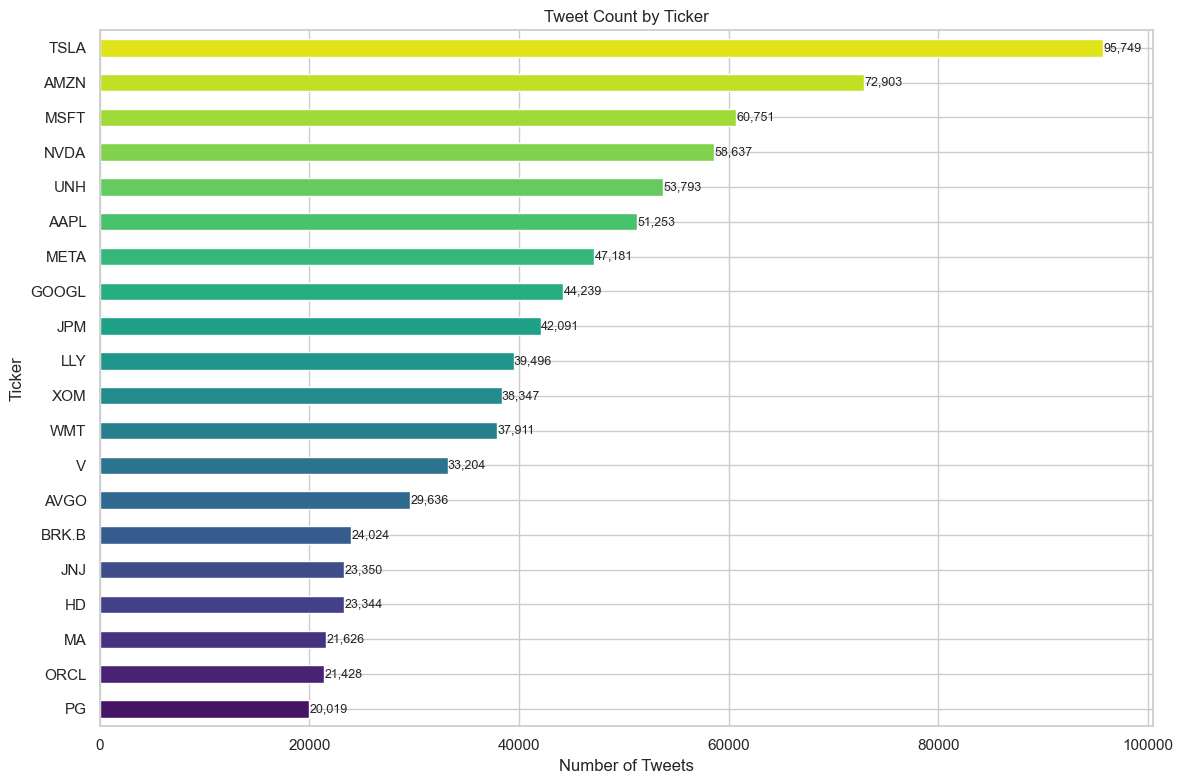


Mean: 41,949
Median: 38,922
Standard Deviation: 19,649


In [26]:
ticker_counts = tweets["ticker"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
ticker_counts.plot(kind="barh", ax=ax, color=sns.color_palette("viridis", len(ticker_counts)))
ax.set_xlabel("Number of Tweets")
ax.set_ylabel("Ticker")
ax.set_title("Tweet Count by Ticker")

for i, v in enumerate(ticker_counts):
    ax.text(v + 20, i, f"{v:,}", va="center", fontsize=9)

plt.tight_layout()
fig.savefig(BASE_DIR / "Report" / "eda_tweets_by_ticker.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\nMean: {ticker_counts.mean():,.0f}")
print(f"Median: {ticker_counts.median():,.0f}")
print(f"Standard Deviation: {ticker_counts.std():,.0f}")

## 4. Date Range and Temporal Coverage

In [27]:
# Date range per ticker
date_ranges = tweets.groupby("ticker")["post_date"].agg(["min", "max", "count"]).sort_values("count", ascending=False)
date_ranges.columns = ["Earliest", "Latest", "Count"]
display(date_ranges)

,Earliest,Latest,Count
ticker,,,
TSLA,2023-09-01 23:54:07+00:00,2026-03-02 23:58:46+00:00,95749
AMZN,2023-09-01 23:50:21+00:00,2026-03-04 16:34:47+00:00,72903
MSFT,2023-09-01 23:33:58+00:00,2026-03-02 23:59:09+00:00,60751
NVDA,2023-09-03 23:35:15+00:00,2026-03-02 23:58:46+00:00,58637
UNH,2023-09-01 17:04:53+00:00,2026-03-02 23:43:23+00:00,53793
AAPL,2023-09-01 23:50:00+00:00,2026-03-02 23:59:42+00:00,51253
META,2023-09-01 21:34:49+00:00,2026-03-02 23:55:52+00:00,47181
GOOGL,2023-09-01 22:46:31+00:00,2026-03-02 23:57:01+00:00,44239
JPM,2023-09-01 02:23:35+00:00,2026-03-02 23:50:03+00:00,42091


Tweets before 2023-10-01: 3,831 (0.46%) — excluded from plot


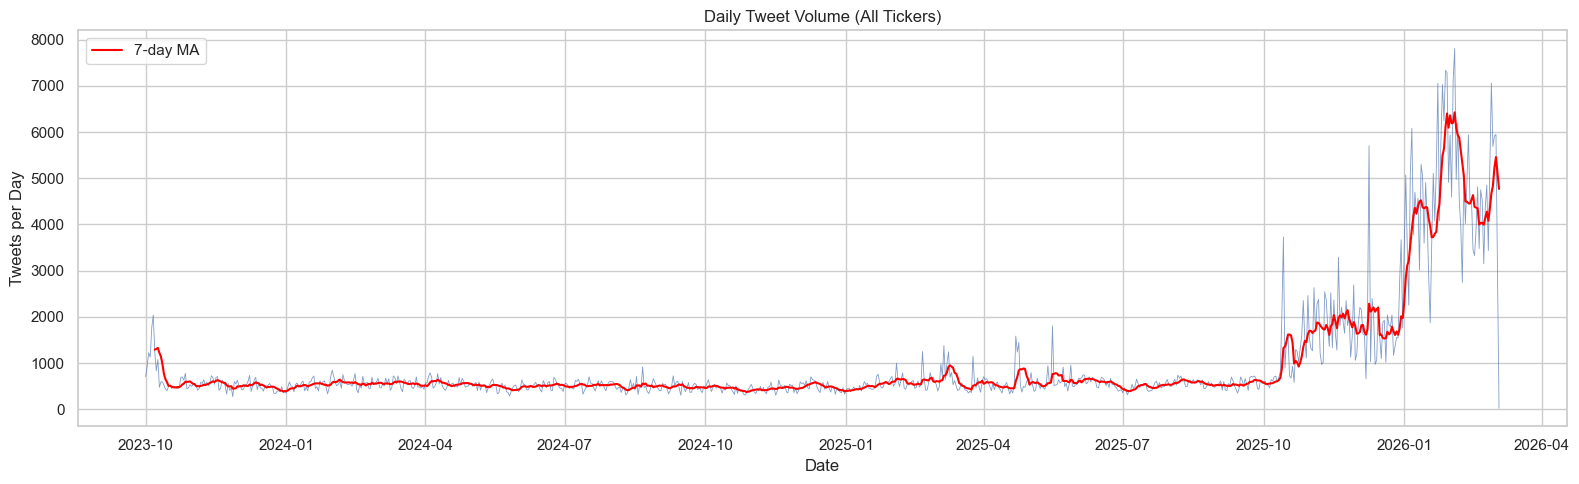

Average tweets per day: 943.7
Max tweets in a day: 7812 (2026-02-03)
Min tweets in a day: 21 (2026-03-04)


In [28]:
# Daily tweet volume across all tickers
daily_counts = tweets.groupby("date_only").size()

# Filter to the actual scraping window (drop stray old tweets)
cutoff = pd.Timestamp("2023-10-01").date()
early_outliers = daily_counts[daily_counts.index < cutoff]
print(f"Tweets before {cutoff}: {early_outliers.sum():,} "
      f"({early_outliers.sum()/daily_counts.sum()*100:.2f}%) — excluded from plot")

daily_counts = daily_counts[daily_counts.index >= cutoff]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_counts.index, daily_counts.values, linewidth=0.6, alpha=0.7)
ax.set_xlabel("Date")
ax.set_ylabel("Tweets per Day")
ax.set_title("Daily Tweet Volume (All Tickers)")

# Add 7-day rolling average
rolling = daily_counts.rolling(7).mean()
ax.plot(rolling.index, rolling.values, color="red", linewidth=1.5, label="7-day MA")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Average tweets per day: {daily_counts.mean():.1f}")
print(f"Max tweets in a day: {daily_counts.max()} ({daily_counts.idxmax()})")
print(f"Min tweets in a day: {daily_counts.min()} ({daily_counts.idxmin()})")

C:\Users\Alasteir\AppData\Local\Temp\ipykernel_30004\1287609782.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  tweets["year_month"] = tweets["post_date"].dt.to_period("M")


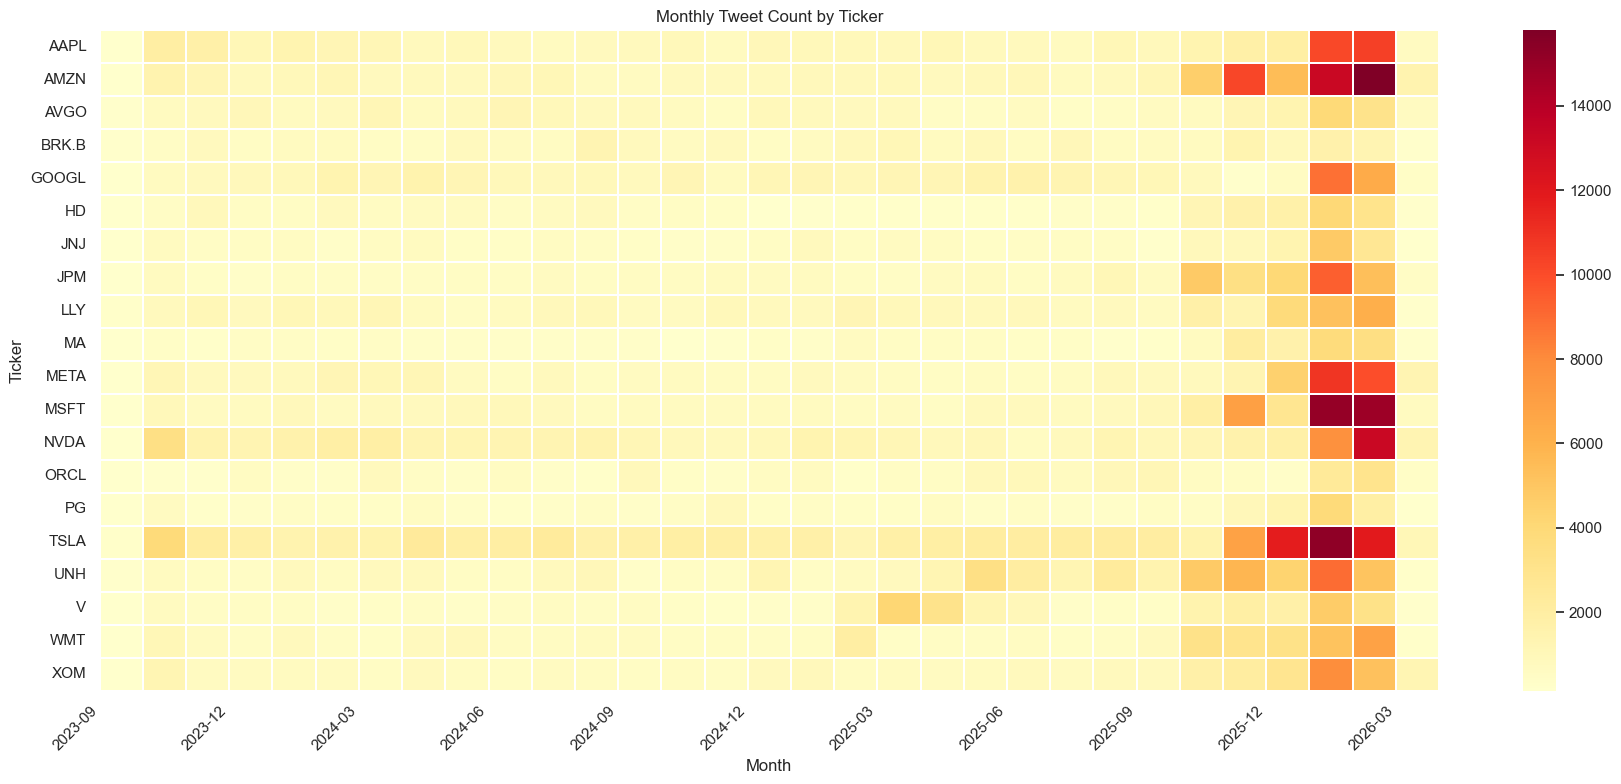

In [29]:
# Monthly tweet volume by ticker (heatmap)
tweets["year_month"] = tweets["post_date"].dt.to_period("M")
monthly_ticker = tweets.groupby(["year_month", "ticker"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(monthly_ticker.T, cmap="YlOrRd", ax=ax, linewidths=0.3)
ax.set_title("Monthly Tweet Count by Ticker")
ax.set_xlabel("Month")
ax.set_ylabel("Ticker")

# Reduce x-tick clutter
tick_positions = range(0, len(monthly_ticker.index), 3)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(monthly_ticker.index[i]) for i in tick_positions], rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 5. Engagement Metrics Analysis

In [30]:
# Engagement metrics summary
engagement_cols = ["replies", "retweets", "likes"]
engagement_stats = tweets[engagement_cols].describe()
display(engagement_stats)

# Total engagement
tweets["total_engagement"] = tweets["replies"] + tweets["retweets"] + tweets["likes"]
print(f"\nTotal engagement across all tweets: {tweets['total_engagement'].sum():,}")
print(f"Average engagement per tweet: {tweets['total_engagement'].mean():.1f}")

,replies,retweets,likes
count,838982.000000,838982.000000,838982.000000
mean,3.134735,11.492771,76.962085
std,56.187199,518.138797,2450.943395
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,1.000000
75%,1.000000,1.000000,4.000000
max,25000.000000,178000.000000,526000.000000



Total engagement across all tweets: 76,842,018.0
Average engagement per tweet: 91.6


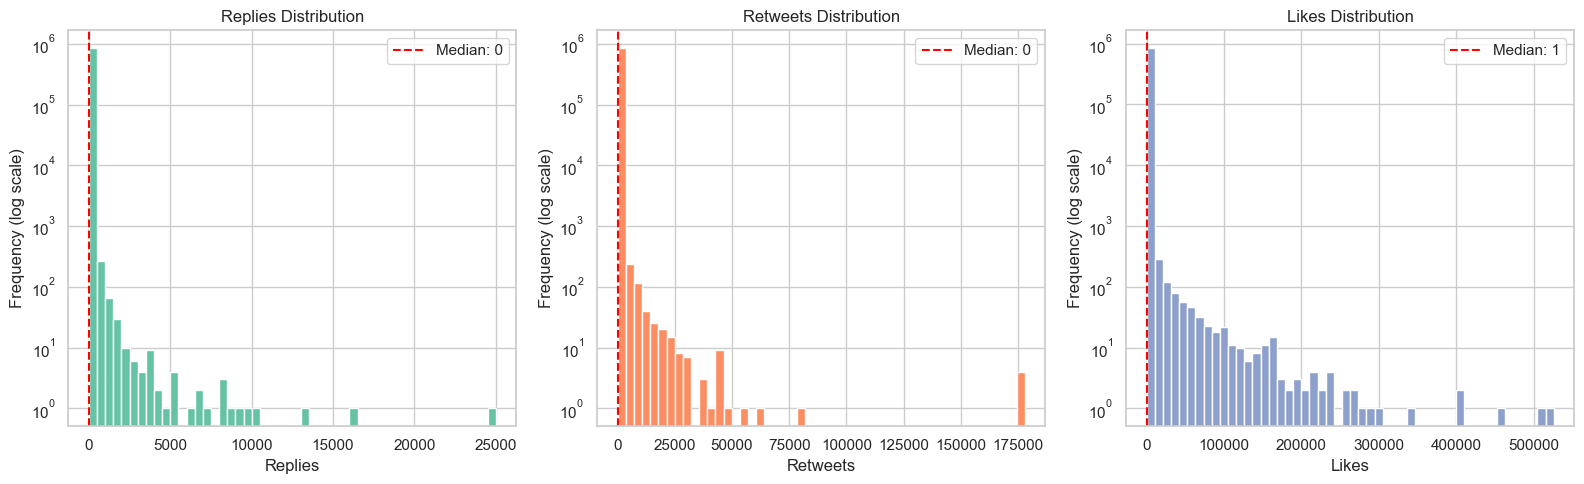

In [31]:
# Distribution of engagement metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(engagement_cols):
    # Use log scale for better visualization (add 1 to handle zeros)
    data = tweets[col] + 1
    axes[i].hist(data, bins=50, color=sns.color_palette("Set2")[i], edgecolor="white", log=True)
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel("Frequency (log scale)")
    axes[i].set_title(f"{col.capitalize()} Distribution")
    axes[i].axvline(tweets[col].median() + 1, color="red", linestyle="--", label=f"Median: {tweets[col].median():.0f}")
    axes[i].legend()

plt.tight_layout()
plt.show()

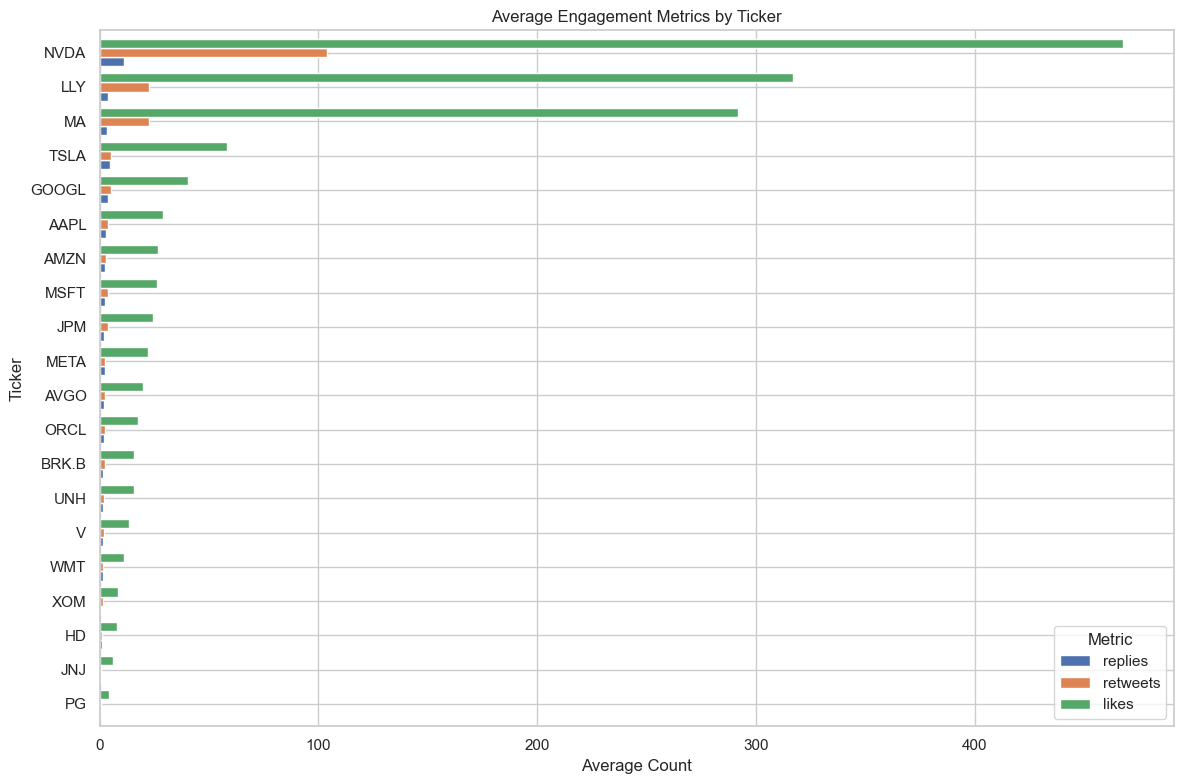

In [32]:
# Average engagement by ticker
engagement_by_ticker = tweets.groupby("ticker")[engagement_cols].mean().sort_values("likes", ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
engagement_by_ticker.plot(kind="barh", ax=ax, width=0.8)
ax.set_xlabel("Average Count")
ax.set_ylabel("Ticker")
ax.set_title("Average Engagement Metrics by Ticker")
ax.legend(title="Metric")
plt.tight_layout()
plt.show()

In [33]:
# Top 10 most engaged tweets
top_tweets = tweets.nlargest(10, "total_engagement")[["ticker", "body", "likes", "retweets", "replies", "total_engagement", "post_date"]]
print("Top 10 Most Engaged Tweets:")
for idx, row in top_tweets.iterrows():
    print(f"\n[{row['ticker']}] {row['total_engagement']:,} engagement ({row['likes']:,} likes, {row['retweets']:,} RT, {row['replies']:,} replies)")
    print(f"  {row['body'][:150]}..." if len(str(row['body'])) > 150 else f"  {row['body']}")

Top 10 Most Engaged Tweets:

[MA] 616,300.0 engagement (526,000.0 likes, 81,000 RT, 9,300 replies)
  If we talking about drugs let’s talk about Epstein and friends drugging underage girls to rape them. Why yall don’t wanna talk about the Epstein files...

[LLY] 570,000.0 engagement (513,000.0 likes, 32,000 RT, 25,000 replies)
  Happy Valentine’s Day

[NVDA] 508,000.0 engagement (454,000.0 likes, 38,000 RT, 16,000 replies)
  Starship flies again next month

[NVDA] 458,000.0 engagement (410,000.0 likes, 38,000 RT, 10,000 replies)
  Back where we belong. Now back to work!

[LLY] 433,700.0 engagement (401,000.0 likes, 23,000 RT, 9,700 replies)
  Still kinda hot tbh

[NVDA] 372,819.0 engagement (345,000.0 likes, 27,000 RT, 819 replies)
  I know you kill people

[NVDA] 344,400.0 engagement (287,000.0 likes, 56,000 RT, 1,400 replies)
  Holy shit. This is how it’s done… “I am wondering if you’re all p*dophiles…because you don’t seem to care that children are being se*ually abused…so t...

[LLY

## 6. Tweet Body Length Analysis

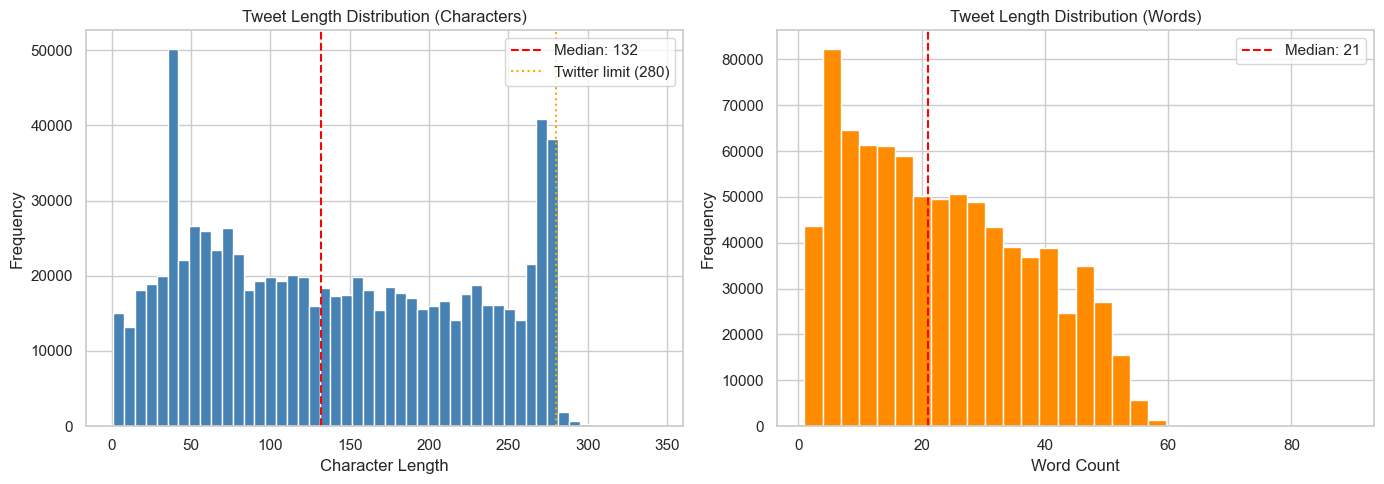

Tweet character length - Mean: 139.9, Median: 132, Std: 84.8
Tweet word count       - Mean: 23.1, Median: 21, Std: 14.5


In [34]:
tweets["body_len"] = tweets["body"].astype(str).str.len()
tweets["body_word_count"] = tweets["body"].astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(tweets["body_len"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Character Length")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Tweet Length Distribution (Characters)")
axes[0].axvline(tweets["body_len"].median(), color="red", linestyle="--", label=f"Median: {tweets['body_len'].median():.0f}")
axes[0].axvline(280, color="orange", linestyle=":", label="Twitter limit (280)")
axes[0].legend()

axes[1].hist(tweets["body_word_count"], bins=30, color="darkorange", edgecolor="white")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Tweet Length Distribution (Words)")
axes[1].axvline(tweets["body_word_count"].median(), color="red", linestyle="--", label=f"Median: {tweets['body_word_count'].median():.0f}")
axes[1].legend()

plt.tight_layout()
fig.savefig(BASE_DIR / "Report" / "eda_tweets_length.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Tweet character length - Mean: {tweets['body_len'].mean():.1f}, Median: {tweets['body_len'].median():.0f}, Std: {tweets['body_len'].std():.1f}")
print(f"Tweet word count       - Mean: {tweets['body_word_count'].mean():.1f}, Median: {tweets['body_word_count'].median():.0f}, Std: {tweets['body_word_count'].std():.1f}")

## 7. Day-of-Week and Hour Distribution

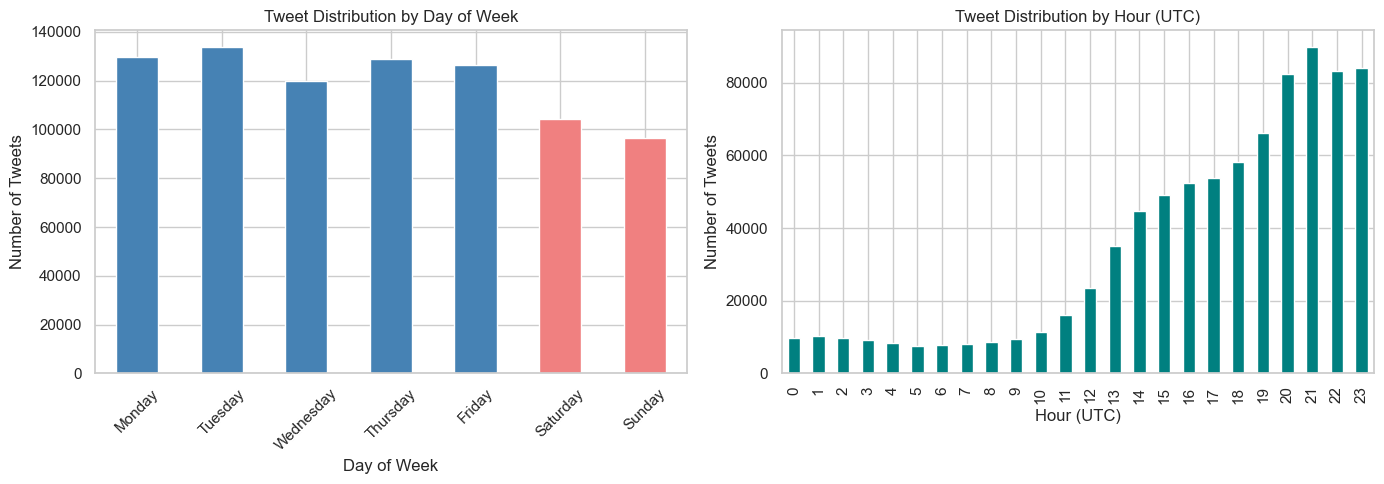

Weekday tweets: 638,334 (76.1%)
Weekend tweets: 200,648 (23.9%)


In [35]:
tweets["day_of_week"] = tweets["post_date"].dt.day_name()
tweets["hour"] = tweets["post_date"].dt.hour

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_counts = tweets["day_of_week"].value_counts().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Day of week
dow_counts.plot(kind="bar", ax=axes[0], color=["steelblue"]*5 + ["lightcoral"]*2)
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Number of Tweets")
axes[0].set_title("Tweet Distribution by Day of Week")
axes[0].tick_params(axis="x", rotation=45)

# Hour of day
hour_counts = tweets["hour"].value_counts().sort_index()
hour_counts.plot(kind="bar", ax=axes[1], color="teal")
axes[1].set_xlabel("Hour (UTC)")
axes[1].set_ylabel("Number of Tweets")
axes[1].set_title("Tweet Distribution by Hour (UTC)")

plt.tight_layout()
plt.show()

weekday = dow_counts[:5].sum()
weekend = dow_counts[5:].sum()
print(f"Weekday tweets: {weekday:,} ({weekday/len(tweets)*100:.1f}%)")
print(f"Weekend tweets: {weekend:,} ({weekend/len(tweets)*100:.1f}%)")

## 7.5 UTC-to-NYSE Session Assignment EDA

The above hour distribution uses raw UTC timestamps. This section converts to Eastern Time (ET) and shows how the 16:00 ET market-close cutoff would distribute tweets across NYSE trading sessions.

- **Article volume by ET hour** — tweet activity relative to the 16:00 ET cutoff
- **Same vs next session split** — overall and per-ticker breakdown of reassignments
- **Day-of-week distribution (ET)** — weekend tweets are always pushed to Monday's session

Total tweets (raw):                        838,982
At/before 16:00 ET -> same session:        506,808 (60.4%)
After 16:00 ET     -> next session:        332,174 (39.6%)
Posted on weekends (ET, pushed to Monday): 197,984 (23.6%)


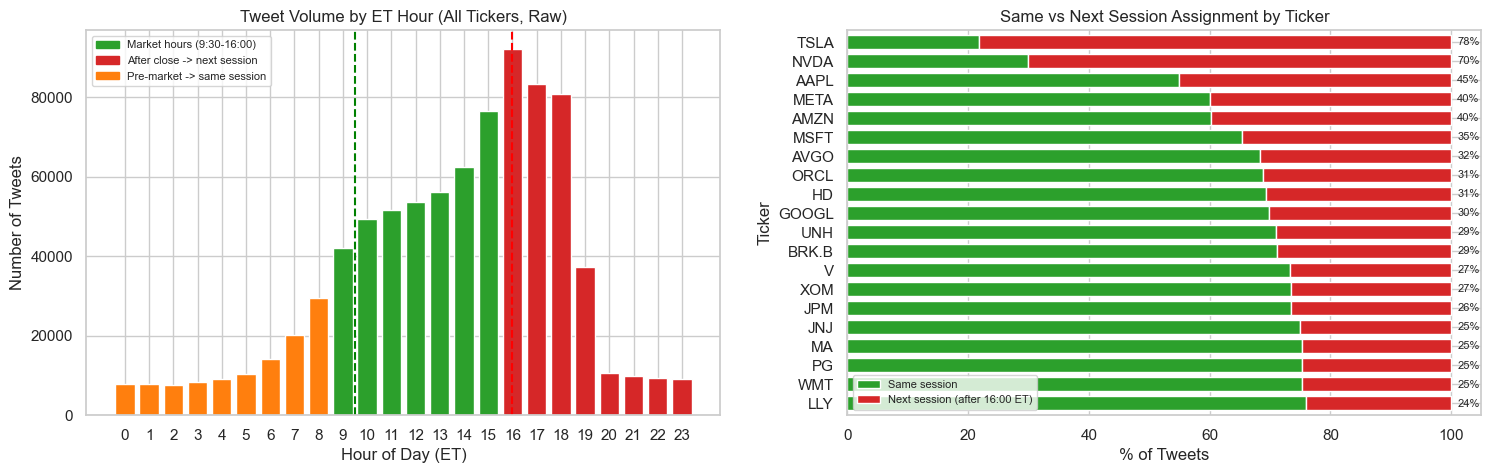

In [36]:
import matplotlib.patches as mpatches

# tweets["post_date"] is datetime64[us, UTC] - convert to ET
tweets["post_date_et"] = tweets["post_date"].dt.tz_convert("America/New_York")

sec = (
    tweets["post_date_et"].dt.hour * 3600
    + tweets["post_date_et"].dt.minute * 60
    + tweets["post_date_et"].dt.second
)
tweets["after_close"] = sec > 16 * 3600
tweets["hour_et"] = tweets["post_date_et"].dt.hour
tweets["day_of_week_et"] = tweets["post_date_et"].dt.day_name()

total = len(tweets)
n_after = tweets["after_close"].sum()
n_before = total - n_after

print(f"Total tweets (raw):                        {total:,}")
print(f"At/before 16:00 ET -> same session:        {n_before:,} ({n_before/total*100:.1f}%)")
print(f"After 16:00 ET     -> next session:        {n_after:,} ({n_after/total*100:.1f}%)")

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = tweets["day_of_week_et"].value_counts().reindex(day_order).fillna(0).astype(int)
weekend_n = int(dow[["Saturday", "Sunday"]].sum())
print(f"Posted on weekends (ET, pushed to Monday): {weekend_n:,} ({weekend_n/total*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Plot 1: ET hour distribution 
hour_counts = tweets["hour_et"].value_counts().sort_index()

def hour_color(h):
    if 9 <= h < 16:
        return "#2ca02c"
    elif h >= 16:
        return "#d62728"
    else:
        return "#ff7f0e"

colors = [hour_color(h) for h in hour_counts.index]
axes[0].bar(hour_counts.index, hour_counts.values, color=colors, edgecolor="white", width=0.8)
axes[0].axvline(9.5, color="green", linestyle="--", linewidth=1.5)
axes[0].axvline(16,  color="red",   linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Hour of Day (ET)")
axes[0].set_ylabel("Number of Tweets")
axes[0].set_title("Tweet Volume by ET Hour (All Tickers, Raw)")
axes[0].set_xticks(range(0, 24))
patch_mkt  = mpatches.Patch(color="#2ca02c", label="Market hours (9:30-16:00)")
patch_post = mpatches.Patch(color="#d62728", label="After close -> next session")
patch_pre  = mpatches.Patch(color="#ff7f0e", label="Pre-market -> same session")
axes[0].legend(handles=[patch_mkt, patch_post, patch_pre], fontsize=8)

# Plot 2: Same vs next session by ticker
ticker_split = (
    tweets.groupby("ticker")["after_close"]
    .agg(after_close_n="sum", total="count")
    .assign(
        same_pct=lambda d: (d["total"] - d["after_close_n"]) / d["total"] * 100,
        next_pct=lambda d: d["after_close_n"] / d["total"] * 100,
    )
    .sort_values("next_pct")
)
ticker_split[["same_pct", "next_pct"]].plot(
    kind="barh", stacked=True, ax=axes[1],
    color=["#2ca02c", "#d62728"], width=0.75,
)
axes[1].set_xlabel("% of Tweets")
axes[1].set_ylabel("Ticker")
axes[1].set_title("Same vs Next Session Assignment by Ticker")
axes[1].legend(["Same session", "Next session (after 16:00 ET)"], fontsize=8)
axes[1].set_xlim(0, 105)
for i, (_, row) in enumerate(ticker_split.iterrows()):
    axes[1].text(101, i, f"{row['next_pct']:.0f}%", va="center", fontsize=8)


## 8. Duplicate and Data Quality Analysis

In [37]:
# Check for duplicate tweet bodies
dup_bodies = tweets["body"].duplicated().sum()
dup_full = tweets.duplicated().sum()

print(f"Duplicate tweet bodies (Same text, different Ticker): {dup_bodies:,} ({dup_bodies/len(tweets)*100:.1f}%)")
print(f"Fully duplicate rows (Summation of duplicates per ticker): {dup_full:,} ({dup_full/len(tweets)*100:.1f}%)")

# Duplicate body counts per ticker (per file)
print("\nDuplicate bodies per ticker:")
dup_per_ticker = tweets.groupby("ticker")["body"].apply(lambda x: x.duplicated().sum())
dup_total_per_ticker = tweets.groupby("ticker").size()
dup_pct = (dup_per_ticker / dup_total_per_ticker * 100).round(2)
dup_df = pd.DataFrame({"Duplicate Bodies": dup_per_ticker, "Total": dup_total_per_ticker, "Duplicate %": dup_pct})
dup_df = dup_df.sort_values("Duplicate Bodies", ascending=False)
display(dup_df)

# Tweets appearing across multiple tickers
body_ticker_count = tweets.groupby("body")["ticker"].nunique()
cross_ticker = body_ticker_count[body_ticker_count > 1]
print(f"\nTweets mentioning multiple tickers: {len(cross_ticker):,}")

if len(cross_ticker) > 0:
    print("\nSample cross-ticker tweets:")
    for body in cross_ticker.sort_values(ascending=False).head(5).index:
        tickers = tweets[tweets["body"] == body]["ticker"].unique()
        print(f"  [{', '.join(tickers)}] {str(body)[:100]}")

Duplicate tweet bodies (Same text, different Ticker): 166,651 (19.9%)
Fully duplicate rows (Summation of duplicates per ticker): 0 (0.0%)

Duplicate bodies per ticker:


,Duplicate Bodies,Total,Duplicate %
ticker,,,
TSLA,11893,95749,12.42
UNH,11340,53793,21.08
WMT,9363,37911,24.70
AMZN,9259,72903,12.70
MSFT,6491,60751,10.68
V,6429,33204,19.36
XOM,6361,38347,16.59
LLY,6347,39496,16.07
MA,6306,21626,29.16



Tweets mentioning multiple tickers: 43,314

Sample cross-ticker tweets:
  [AMZN, BRK.B, JNJ, JPM, LLY, MSFT, PG, UNH, V, WMT] الاكثر نشاطا: $NVDA $WBD $WVE $CFLT $NFLX $INTC $TSLA $SOFI $MRVL $CORE $AAPL $AMZN $BAC $GOOGL $AMD
  [BRK.B, HD, JNJ, JPM, MA, V] الأكثر نشاطًا حتى الآن: $CRH $PLTR $CRWV $FER $LRCX $C $CVNA $AMAT $NOW $BRK.B $ALNY $COST $NVDA $FI
  [AAPL, BRK.B, JPM, MSFT, NVDA, XOM] Top 25 Stocks Institutional Investors Own $MSFT $AAPL $NVDA $AMZN $META $LLY $GOOGL $AVGO $GOOG $UNH
  [AMZN, JPM, PG, UNH, V, WMT] الاكثر نشاطا حتى الآن: $NVDA $INTC $TSLA $SOFI $IREN $BITM $AAPL $AMD $AMZN $PLTR $STRY $GOOGL $BAC 
  [AAPL, BRK.B, MSFT, NVDA, TSLA, XOM] Top 25 Stocks Institutional Investors Own $MSFT $AAPL $NVDA $AMZN $META $GOOGL $LLY $AVGO $GOOG $UNH


In [38]:
# Check for empty or very short tweets
empty_tweets = tweets[tweets["body"].isna() | (tweets["body"] == "")]
short_tweets = tweets[tweets["body_len"] < 10]

print(f"Empty tweets: {len(empty_tweets):,}")
print(f"Very short tweets (<10 chars): {len(short_tweets):,}")

if len(short_tweets) > 0:
    print("\nSample short tweets:")
    for _, row in short_tweets.head(5).iterrows():
        print(f"  [{row['ticker']}] '{row['body']}'")

Empty tweets: 51
Very short tweets (<10 chars): 17,257

Sample short tweets:
  [AAPL] '$AAPl'
  [AAPL] 'aka $aapl'
  [AAPL] '$aapl'
  [AAPL] '= $AAPL'
  [AAPL] '$AAPL'


## 8.5 Language Breakdown

Languages detected: 69

Top 10 languages:


,Count,%
language,,
en,658252,78.46
ja,20618,2.46
ko,17513,2.09
es,14383,1.71
nl,10187,1.21
cy,8393,1.00
st,7409,0.88
de,6812,0.81
ar,5943,0.71


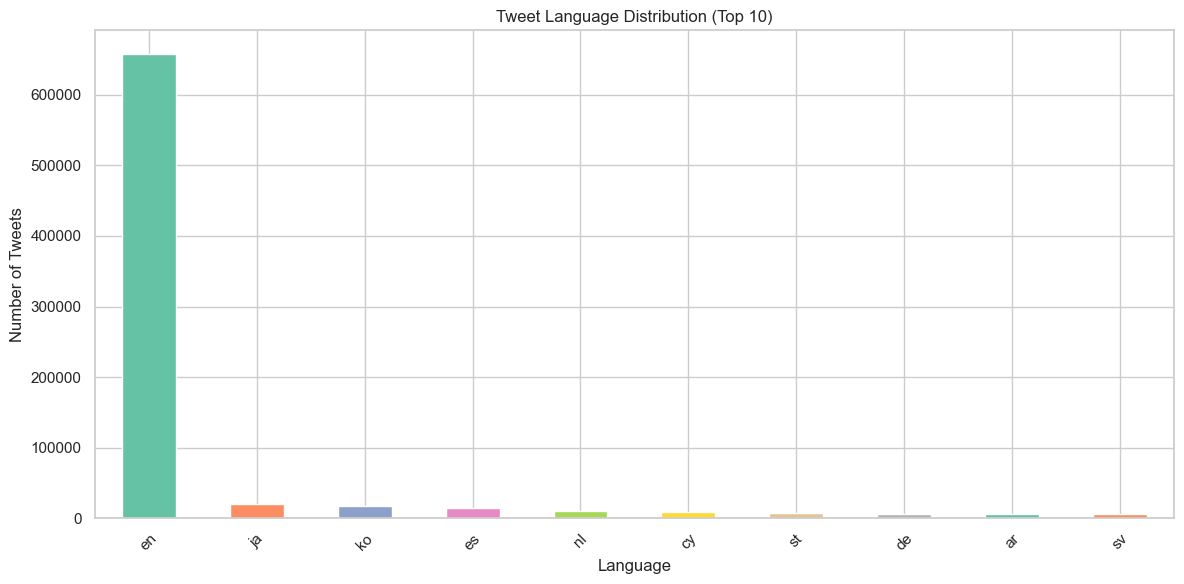


English tweets: 658,252 (78.5%)
Non-English tweets: 180,730 (21.5%)


In [39]:
from lingua import LanguageDetectorBuilder

# Build detector for all languages
detector = LanguageDetectorBuilder.from_all_languages().build()

def detect_lang(text):
    try:
        text = str(text).replace("\n", " ").strip()
        if not text or len(text) < 3:
            return "unknown"
        lang = detector.detect_language_of(text)
        return lang.iso_code_639_1.name.lower() if lang else "unknown"
    except:
        return "unknown"

tweets["language"] = tweets["body"].apply(detect_lang)

# Language breakdown
lang_counts = tweets["language"].value_counts()
total = len(tweets)

print(f"Languages detected: {len(lang_counts)}")
print(f"\nTop 10 languages:")
lang_df = pd.DataFrame({
    "Count": lang_counts,
    "%": (lang_counts / total * 100).round(2)
})
display(lang_df.head(10))

# Plot top 10 languages
fig, ax = plt.subplots(figsize=(12, 6))
lang_counts.head(10).plot(kind="bar", ax=ax, color=sns.color_palette("Set2", 10))
ax.set_xlabel("Language")
ax.set_ylabel("Number of Tweets")
ax.set_title("Tweet Language Distribution (Top 10)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
fig.savefig(BASE_DIR / "Report" / "eda_tweets_language.png", dpi=200, bbox_inches="tight")
plt.show()

# English vs non-English
en_count = lang_counts.get("en", 0)
non_en = total - en_count
print(f"\nEnglish tweets: {en_count:,} ({en_count/total*100:.1f}%)")
print(f"Non-English tweets: {non_en:,} ({non_en/total*100:.1f}%)")

## 8.6 Link / URL Analysis

Count how many tweets contain hyperlinks, extract every URL, and classify
them by domain type (e.g. link-shortener, financial-data, news, social media, image, other).

Tweets with at least one URL: 317 / 838,982 (0.04%)
Tweets without any URL:       838,665 / 838,982 (99.96%)
Total URL occurrences:        335
Average URLs per tweet (overall): 0.0004
Average URLs per tweet (with URL): 1.06


,Link Type,Count,% of All URLs
0,Other,249,74.3%
1,Link Shortener,63,18.8%
2,Financial / Trading,11,3.3%
3,Image / Media File,6,1.8%
4,Malformed / Artefact,3,0.9%
5,News / Media,2,0.6%
6,Social Media,1,0.3%


,Domain,Count,Category
0,wa.me,175,Other
1,amz,67,Other
2,buff.ly,62,Link Shortener
3,aotetf.com,4,Financial / Trading
4,tickeron.com,3,Financial / Trading
5,tech_brand_value.jpg,2,Image / Media File
6,tradershub.ninja,2,Financial / Trading
7,join%2520for%2520$1%2520%e2%86%92%,1,Malformed / Artefact
8,$1%2520trial%2520link%2520%e2%86%92%,1,Malformed / Artefact
9,asml_financials.jpg,1,Image / Media File


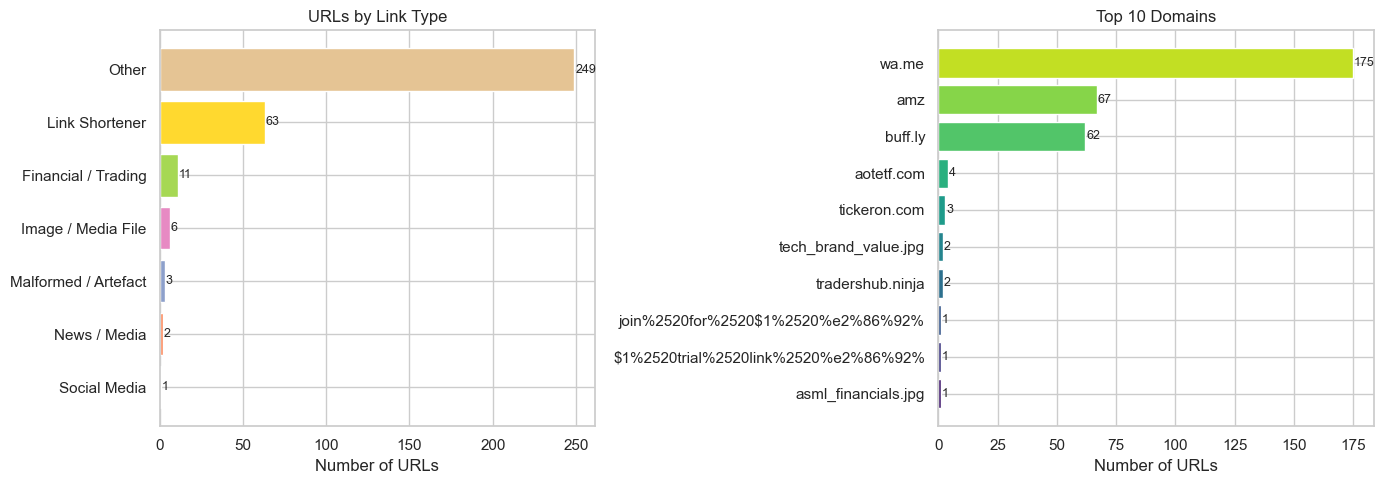


Sample tweets containing URLs (5 shown):

  [AAPL] ['https://buff.ly/3WGTrpL']
    Apple will reportedly release artificial intelligence features in October, weeks after iOS 18 update $AAPL #chatgpt #openai #artificialintelligence #generativeai #apple #iphone #ioshttps://buff.ly/3WG

  [AAPL] ['https://tickeron.com/trading-investing-101/momentum-stock-trading-powered-by-tickeron-ai/']
    Momentum Stock Trading Powered by Tickeron AIhttps://tickeron.com/trading-investing-101/momentum-stock-trading-powered-by-tickeron-ai/ $NVDA $MSFT $AAPL $AMZN $GOOG $GOOGL $META $AVGO $TSM $LLY $WMT $

  [AAPL] ['http://Join%2520for%2520$1%2520%E2%86%92%']
    Theme: AI/datacenter core: $TSLA $NVDA $AAPL. Pullback playbook + live tape. $1 http://Join%2520for%2520$1%2520%E2%86%92% 2520tinyurl.com/TTN1DOLLAR

  [AAPL] ['http://$1%2520trial%2520link%2520%E2%86%92%']
    Leaders: Double‑ticker heat: $AAPL & $MSFT. Trend or fade?. $1 gets you in — watchlists + alerts http://$1%2520trial%2520link%2520%E2%8

In [40]:
import re
from urllib.parse import urlparse
from collections import Counter

# Extract URLs from tweet bodies 
url_pattern = re.compile(r'https?://\S+')
tweets["urls"] = tweets["body"].astype(str).str.findall(url_pattern)
tweets["has_url"] = tweets["urls"].str.len() > 0
tweets["url_count"] = tweets["urls"].str.len()

total = len(tweets)
with_urls = tweets["has_url"].sum()
total_urls = tweets["url_count"].sum()

print(f"Tweets with at least one URL: {with_urls:,} / {total:,} ({with_urls/total*100:.2f}%)")
print(f"Tweets without any URL:       {total - with_urls:,} / {total:,} ({(total-with_urls)/total*100:.2f}%)")
print(f"Total URL occurrences:        {total_urls:,}")
print(f"Average URLs per tweet (overall): {total_urls/total:.4f}")
if with_urls > 0:
    print(f"Average URLs per tweet (with URL): {total_urls/with_urls:.2f}")

# Parse domains
flat_urls = [u for urls in tweets["urls"] for u in urls]

domain_list = []
for u in flat_urls:
    try:
        # Clean trailing punctuation that may be captured
        u_clean = re.sub(r'[),;:\'"!?\]>]+$', '', u)
        d = urlparse(u_clean).netloc.lower().replace("www.", "")
        if d:
            domain_list.append(d)
        else:
            domain_list.append("[no-domain]")
    except Exception:
        domain_list.append("[parse-error]")

domain_counts = Counter(domain_list)

# Classify link types 
LINK_CATEGORIES = {
    "Link Shortener": ["buff.ly", "bit.ly", "t.co", "tinyurl.com", "ow.ly",
                       "goo.gl", "is.gd", "shorturl.at", "rb.gy", "cutt.ly"],
    "Financial / Trading": ["tickeron.com", "tickeron.coma", "tradershub.ninja",
                            "aotetf.com", "tradingwiser.com", "finance.yahoo.com",
                            "stocktwits.com", "investing.com", "seekingalpha.com",
                            "benzinga.com", "marketwatch.com"],
    "News / Media": ["reuters.com", "cnbc.com", "bloomberg.com", "wsj.com",
                     "nytimes.com", "bbc.com", "nejm.org",
                     "michaelparekh.substack.com", "substack.com"],
    "Social Media": ["twitter.com", "x.com", "reddit.com", "youtube.com",
                     "youtu.be", "instagram.com", "facebook.com", "tiktok.com",
                     "linkedin.com", "threads.net", "discord.gg", "discord.com"],
    "Image / Media File": [],  # holds .jpg/.png/.gif domains below
}

def classify_domain(domain):
    for cat, domains in LINK_CATEGORIES.items():
        if domain in domains:
            return cat
    # Check if domain looks like an image filename (scraping artefact)
    if re.search(r'\.(jpg|jpeg|png|gif|webp|svg|bmp)$', domain):
        return "Image / Media File"
    # Check for percent-encoded / malformed domains (scraping artefact)
    if "%" in domain or domain.startswith("["):
        return "Malformed / Artefact"
    return "Other"

category_counts = Counter()
domain_to_cat = {}
for domain, count in domain_counts.items():
    cat = classify_domain(domain)
    category_counts[cat] += count
    domain_to_cat[domain] = cat

# Display results
cat_df = pd.DataFrame(
    [(cat, cnt, f"{cnt/total_urls*100:.1f}%") for cat, cnt in category_counts.most_common()],
    columns=["Link Type", "Count", "% of All URLs"]
)
display(cat_df)

dom_df = pd.DataFrame(
    [(d, c, domain_to_cat[d]) for d, c in domain_counts.most_common()],
    columns=["Domain", "Count", "Category"]
)
display(dom_df)

# Bar chart: link type breakdown 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: link type categories
cats = category_counts.most_common()
ax = axes[0]
ax.barh([c[0] for c in cats][::-1], [c[1] for c in cats][::-1],
        color=sns.color_palette("Set2", len(cats)))
for i, (cat, cnt) in enumerate(reversed(cats)):
    ax.text(cnt + 0.5, i, str(cnt), va="center", fontsize=9)
ax.set_xlabel("Number of URLs")
ax.set_title("URLs by Link Type")

# Right: top domains
top_doms = domain_counts.most_common(10)
ax = axes[1]
ax.barh([d[0] for d in top_doms][::-1], [d[1] for d in top_doms][::-1],
        color=sns.color_palette("viridis", len(top_doms)))
for i, (dom, cnt) in enumerate(reversed(top_doms)):
    ax.text(cnt + 0.3, i, str(cnt), va="center", fontsize=9)
ax.set_xlabel("Number of URLs")
ax.set_title("Top 10 Domains")

plt.tight_layout()
fig.savefig(BASE_DIR / "Report" / "eda_tweets_link_types.png", dpi=200, bbox_inches="tight")
plt.show()

# Sample tweets containing links
print(f"\nSample tweets containing URLs ({min(5, with_urls)} shown):")
url_tweets = tweets[tweets["has_url"]].head(5)
for _, row in url_tweets.iterrows():
    print(f"\n  [{row['ticker']}] {row['urls']}")
    print(f"    {str(row['body'])[:200]}")

## 9. Engagement vs Tweet Length Correlation

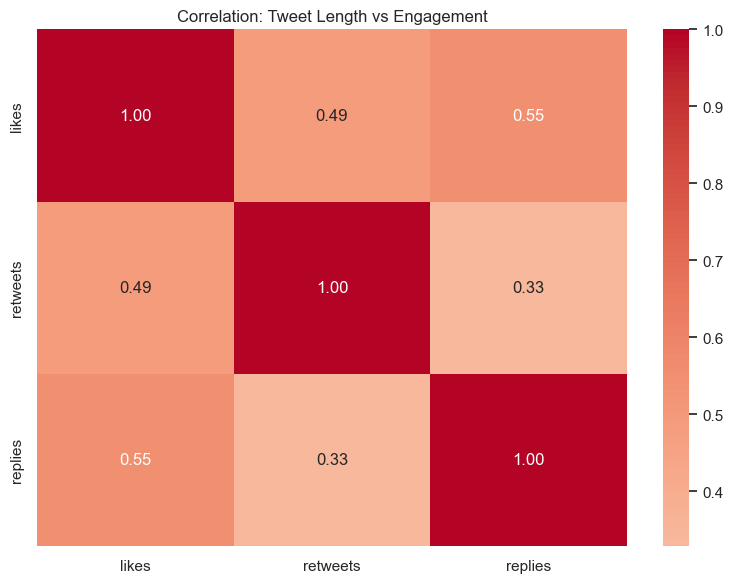

In [41]:
# Correlation between length and engagement
corr_cols = ["likes", "retweets", "replies"]
corr_matrix = tweets[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, ax=ax, fmt=".2f")
ax.set_title("Correlation: Tweet Length vs Engagement")
plt.tight_layout()
plt.show()

## 10. Summary

In [42]:
print("TWEETS DATASET EDA SUMMARY")
print(f"Total tweets:            {len(tweets):,}")
print(f"Tickers:                 {tweets['ticker'].nunique()}")
print(f"Date range:              {tweets['post_date'].min().strftime('%Y-%m-%d')} to {tweets['post_date'].max().strftime('%Y-%m-%d')}")
print(f"Missing bodies:          {tweets['body'].isna().sum():,}")
# Exclude list-typed columns (urls) that cannot be hashed
_dup_cols = [c for c in tweets.columns if tweets[c].dtype != object or not tweets[c].apply(type).eq(list).any()]
print(f"Duplicate rows:          {tweets.duplicated(subset=_dup_cols).sum():,}")
print(f"Avg tweet length:        {tweets['body_len'].mean():.0f} chars / {tweets['body_word_count'].mean():.0f} words")
print(f"Avg tweets per day:      {daily_counts.mean():.1f}")
print(f"\nEngagement metrics:")
print(f"Total likes:           {tweets['likes'].sum():,}")
print(f"Total retweets:        {tweets['retweets'].sum():,}")
print(f"Total replies:         {tweets['replies'].sum():,}")
print(f"Avg likes/tweet:       {tweets['likes'].mean():.1f}")
print(f"Avg retweets/tweet:    {tweets['retweets'].mean():.1f}")

TWEETS DATASET EDA SUMMARY
Total tweets:            838,982
Tickers:                 20
Date range:              2023-09-01 to 2026-03-04
Missing bodies:          51
Duplicate rows:          0
Avg tweet length:        140 chars / 23 words
Avg tweets per day:      943.7

Engagement metrics:
Total likes:           64,569,804.0
Total retweets:        9,642,228
Total replies:         2,629,986
Avg likes/tweet:       77.0
Avg retweets/tweet:    11.5
